In [123]:
import os, random, json, numpy as np
import torch, torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as T
import torchvision.models as tvm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score
import medmnist
from medmnist import INFO

def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class AverageMeter:
    def __init__(self): self.reset()
    def reset(self): self.sum = 0.0; self.cnt = 0
    def update(self, val, n=1): self.sum += float(val) * n; self.cnt += n
    @property
    def avg(self): return self.sum / max(1, self.cnt)

def compute_metrics(y_true, y_prob, n_classes):
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_true, y_pred)
    if n_classes == 2:
        auroc = roc_auc_score(y_true, y_prob[:,1])
    else:
        y_true_1hot = np.eye(n_classes)[y_true]
        try:
            auroc = roc_auc_score(y_true_1hot, y_prob, average="macro", multi_class="ovr")
        except Exception:
            auroc = np.nan
    return {"acc": acc, "auroc": auroc}

def reliability_diagram(y_true, y_prob, n_bins=10):
    confidences = np.max(y_prob, axis=1)
    preds = np.argmax(y_prob, axis=1)
    correct = (preds == y_true).astype(np.float32)
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    bin_accs, bin_confs = [], []
    xs = np.linspace(0.5/n_bins, 1-0.5/n_bins, n_bins)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (confidences > lo) & (confidences <= hi) if i>0 else (confidences >= lo) & (confidences <= hi)
        if mask.sum() == 0:
            bin_accs.append(0.0); bin_confs.append((lo+hi)/2); continue
        acc_i = correct[mask].mean()
        conf_i = confidences[mask].mean()
        frac_i = mask.mean()
        ece += abs(acc_i - conf_i) * frac_i
        bin_accs.append(acc_i); bin_confs.append(conf_i)
    plt.figure(); plt.plot([0,1],[0,1], linestyle='--')
    plt.bar(xs, bin_accs, width=1.0/n_bins, alpha=0.6, edgecolor='k')
    plt.plot(xs, bin_confs, marker='o')
    plt.xlabel("Confidence"); plt.ylabel("Accuracy")
    plt.title(f"Reliability Diagram (ECE={ece:.3f})")
    plt.tight_layout(); plt.show()
    return float(ece)

def get_medmnist_dataset(key: str, split: str, as_rgb=True, size=64, download=True):
    info = INFO[key]
    DataClass = getattr(medmnist, info['python_class'])
    tf = [T.Resize((size,size)), T.ToTensor()]
    if as_rgb: tf.append(T.Lambda(lambda x: x.repeat(3,1,1) if x.shape[0]==1 else x))
    transform = T.Compose(tf)
    return DataClass(split=split, transform=transform, download=download)

def get_loaders(key, batch_size=128, num_workers=2, label_frac=1.0, seed=42):
    set_seed(seed)
    ds_train = get_medmnist_dataset(key, 'train')
    ds_val   = get_medmnist_dataset(key, 'val')
    ds_test  = get_medmnist_dataset(key, 'test')
    n_classes = len(INFO[key]['label'])
    if 0 < label_frac < 1.0:
        y = np.array([int(t[1]) for t in ds_train])
        idxs = []
        for c in np.unique(y):
            cls_idx = np.where(y==c)[0]
            k = max(1, int(len(cls_idx)*label_frac))
            idxs.extend(np.random.choice(cls_idx, size=k, replace=False))
        ds_train = Subset(ds_train, sorted(idxs))
    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, test_loader, n_classes

class SmallCNN(nn.Module):
    def __init__(self, in_ch=3, n_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(128, n_classes)
    def forward(self, x):
        feat = self.net(x).flatten(1)
        return self.fc(feat)

def make_resnet18(n_classes=2, in_ch=3, pretrained=True):
    m = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
    if in_ch != 3:
        w = m.conv1.weight
        m.conv1 = torch.nn.Conv2d(in_ch, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if in_ch == 1:
            with torch.no_grad():
                m.conv1.weight.copy_(w.sum(dim=1, keepdim=True))
    in_dim = m.fc.in_features
    m.fc = torch.nn.Linear(in_dim, n_classes)
    return m

print('✅ Setup ready')

✅ Setup ready


In [124]:
#=================================#
#              WEEK 3             #
#=================================#

import medmnist
from medmnist import INFO

KEY = 'pneumoniamnist'
print(f"Dataset: {INFO[KEY]['python_class']}")
print(f"{KEY} labels: {INFO[KEY]['label']}")  # class labels

DataClass = getattr(medmnist, INFO[KEY]['python_class'])
print(f"Contructor: {DataClass}")

train_ds = DataClass(split='train', download=True) # custom class instance from medmnist
val_ds   = DataClass(split='val',   download=True)
test_ds  = DataClass(split='test',  download=True)
split_ds = [train_ds, val_ds, test_ds]
split_ds_names = ['train_ds', 'val_ds', 'test_ds']

# Split shapes
print('Split shapes:')
print(' train_ds:', train_ds.imgs.shape) # images 28x28
print(' val_ds:', val_ds.imgs.shape)
print(' test_ds:', test_ds.imgs.shape)

# Label counts
print('Label distribution:')
for ds, name in zip(split_ds, split_ds_names):
    unique_labels, counts = np.unique(ds.labels, return_counts=True)
    print(f"{name}")
    for l, i in zip(unique_labels, [0, 1]):
        print(f" {l}: {counts[i]}")

Dataset: PneumoniaMNIST
pneumoniamnist labels: {'0': 'normal', '1': 'pneumonia'}
Contructor: <class 'medmnist.dataset.PneumoniaMNIST'>
Split shapes:
 train_ds: (4708, 28, 28)
 val_ds: (524, 28, 28)
 test_ds: (624, 28, 28)
Label distribution:
train_ds
 0: 1214
 1: 3494
val_ds
 0: 135
 1: 389
test_ds
 0: 234
 1: 390


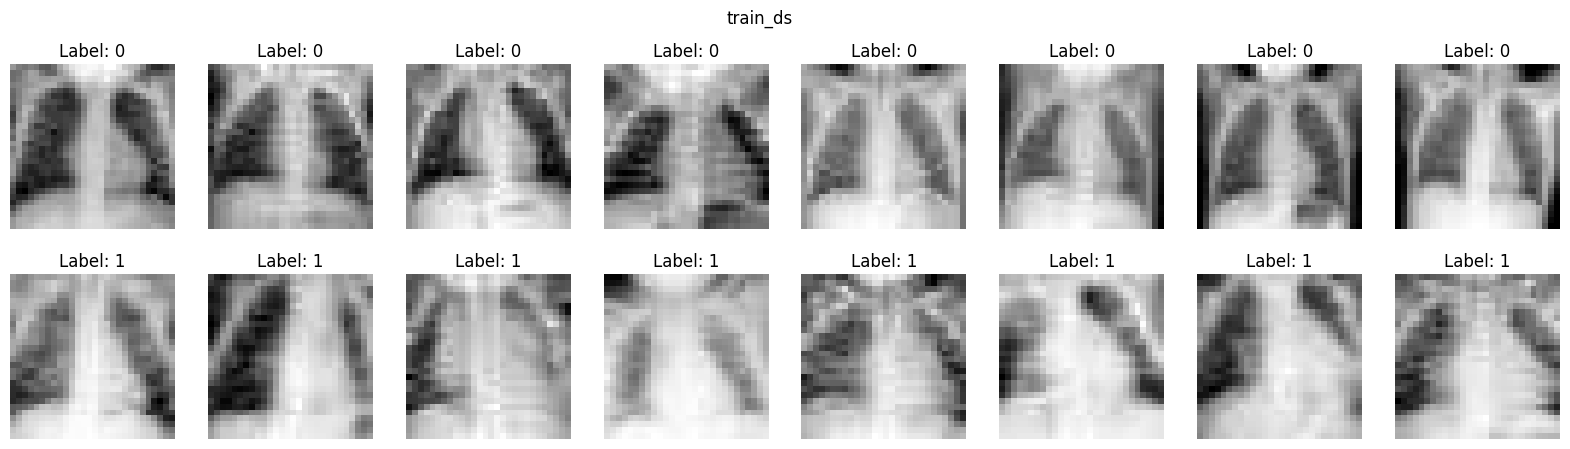

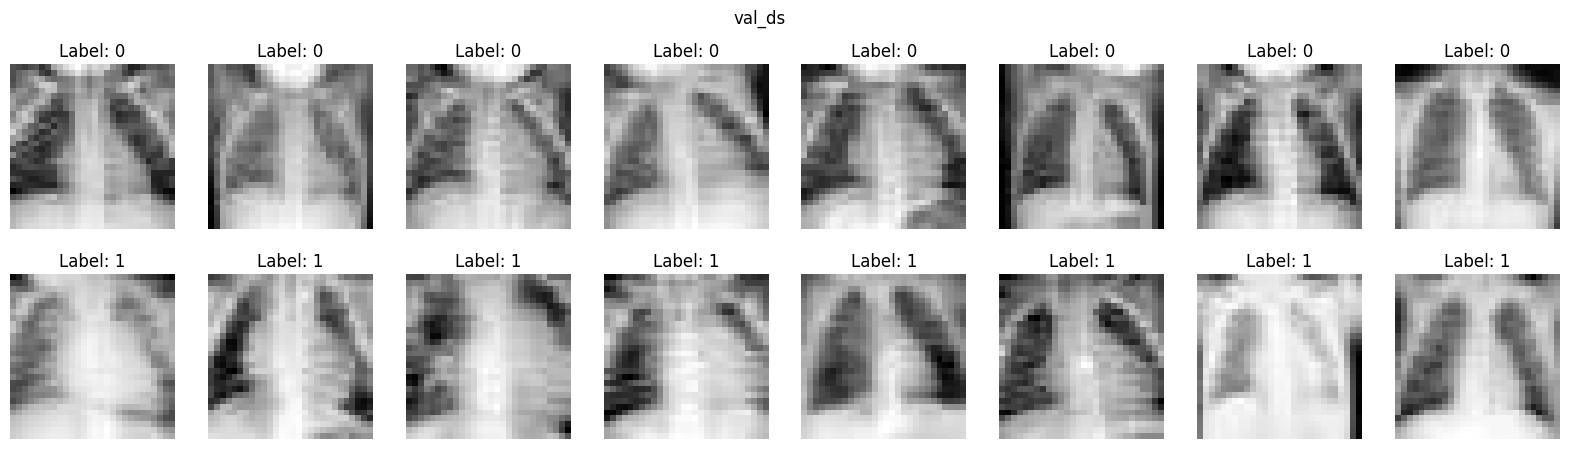

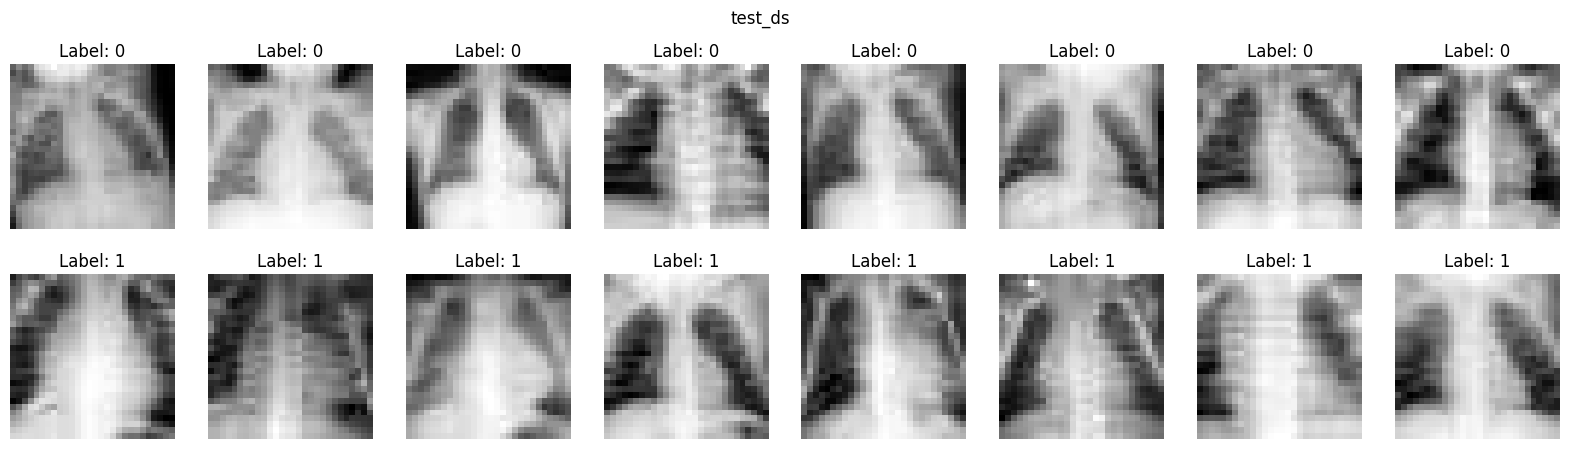

In [125]:
import random
import matplotlib.pyplot as plt
import numpy as np

set_seed(42)

for ds, name in zip(split_ds, split_ds_names):
    fig, axes = plt.subplots(2, 8, figsize=(20,5))
    indx_0 = np.where(ds.labels.flatten() == 0)[0]
    indx_1 = np.where(ds.labels.flatten() == 1)[0]

    # Pick 8 random images for each label
    indx_0 = np.random.choice(indx_0, 8, replace=False)
    indx_1 = np.random.choice(indx_1, 8, replace=False)
    indx = np.concatenate([indx_0, indx_1])

    for ax, i in zip(axes.flatten(), indx):
        ax.imshow(ds.imgs[i], cmap='gray')
        ax.set_title(f"Label: {ds.labels[i][0]}")
        ax.axis('off')

    fig.suptitle(f"{name}")


Comments: images labeled "normal" (0) seem to generally have clearer, darker borders around the lungs while images labeled "pneumonia" (1) seem to have white patches in the center area (where the lung would be), although it is hard to concretely tell based on the low resolution and sample size.

In [126]:
import os, random, json, numpy as np
import torch, torch.nn as nn
from torchmetrics.classification import BinaryCalibrationError
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as T
import torchvision.models as tvm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score
import medmnist
from medmnist import INFO

In [127]:
#=======================================#
# RESNET18 - ALL EPOCHS, ADAM OPTIMIZER #
#=======================================#

def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class AverageMeter:
    def __init__(self): self.reset()
    def reset(self): self.sum = 0.0; self.cnt = 0
    def update(self, val, n=1): self.sum += float(val) * n; self.cnt += n
    @property
    def avg(self): return self.sum / max(1, self.cnt)

def compute_metrics(y_true, y_prob, n_classes):
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_true, y_pred)
    if n_classes == 2:
        auroc = roc_auc_score(y_true, y_prob[:,1])
    else:
        y_true_1hot = np.eye(n_classes)[y_true]
        try:
            auroc = roc_auc_score(y_true_1hot, y_prob, average="macro", multi_class="ovr")
        except Exception:
            auroc = np.nan
    return {"acc": acc, "auroc": auroc}

def reliability_diagram(y_true, y_prob, n_bins=10):
    confidences = np.max(y_prob, axis=1)
    preds = np.argmax(y_prob, axis=1)
    correct = (preds == y_true).astype(np.float32)
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    bin_accs, bin_confs = [], []
    xs = np.linspace(0.5/n_bins, 1-0.5/n_bins, n_bins)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (confidences > lo) & (confidences <= hi) if i>0 else (confidences >= lo) & (confidences <= hi)
        if mask.sum() == 0:
            bin_accs.append(0.0); bin_confs.append((lo+hi)/2); continue
        acc_i = correct[mask].mean()
        conf_i = confidences[mask].mean()
        frac_i = mask.mean()
        ece += abs(acc_i - conf_i) * frac_i
        bin_accs.append(acc_i); bin_confs.append(conf_i)
    plt.figure(); plt.plot([0,1],[0,1], linestyle='--')
    plt.bar(xs, bin_accs, width=1.0/n_bins, alpha=0.6, edgecolor='k')
    plt.plot(xs, bin_confs, marker='o')
    plt.xlabel("Confidence"); plt.ylabel("Accuracy")
    plt.title(f"Reliability Diagram (ECE={ece:.3f})")
    plt.tight_layout(); plt.show()
    return float(ece)

def ece_score(y_true, y_prob, num_classes=2, n_bins=10, norm='l1'):
    ece_metric = BinaryCalibrationError(n_bins=n_bins, norm=norm)
    
    # Convert to tensors if needed
    if isinstance(y_true, torch.Tensor):
        y_true_tensor = y_true
    else:
        y_true_tensor = torch.from_numpy(y_true).long()
    
    if isinstance(y_prob, torch.Tensor):
        y_prob_tensor = y_prob
    else:
        y_prob_tensor = torch.from_numpy(y_prob).float()
    
    # For binary classification, use probability of positive class
    if y_prob_tensor.ndim == 2 and y_prob_tensor.shape[1] == 2:
        y_prob_tensor = y_prob_tensor[:, 1]
    
    return float(ece_metric(y_prob_tensor, y_true_tensor))

def get_medmnist_dataset(key: str, split: str, as_rgb=True, size=64, download=True, use_augmentation=False):
    info = INFO[key]
    DataClass = getattr(medmnist, info['python_class'])
    tf = [T.Resize((size,size))]
    
    # Add augmentations only for training split
    if use_augmentation and split == 'train':
        tf.extend([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=15),  # Small rotation, avoiding large rotations
            #T.ColorJitter(brightness=0.2, contrast=0.2),  # Realistic brightness and contrast changes
        ])
    
    tf.append(T.ToTensor())
    if as_rgb: tf.append(T.Lambda(lambda x: x.repeat(3,1,1) if x.shape[0]==1 else x))
    transform = T.Compose(tf)
    return DataClass(split=split, transform=transform, download=download)

def get_loaders(key, batch_size=128, num_workers=2, label_frac=1.0, seed=42, use_augmentation=False):
    set_seed(seed)
    ds_train = get_medmnist_dataset(key, 'train', use_augmentation=use_augmentation)
    ds_val   = get_medmnist_dataset(key, 'val', use_augmentation=False)
    ds_test  = get_medmnist_dataset(key, 'test', use_augmentation=False)
    n_classes = len(INFO[key]['label'])
    if 0 < label_frac < 1.0:
        y = np.array([int(t[1]) for t in ds_train])
        idxs = []
        for c in np.unique(y):
            cls_idx = np.where(y==c)[0]
            k = max(1, int(len(cls_idx)*label_frac))
            idxs.extend(np.random.choice(cls_idx, size=k, replace=False))
        ds_train = Subset(ds_train, sorted(idxs))
    
    # Set num_workers=0 on Windows to avoid pickling errors
    nw = 0 if os.name == 'nt' else num_workers
    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=nw, pin_memory=pin_mem)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=pin_mem)
    test_loader  = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=pin_mem)
    
    return train_loader, val_loader, test_loader, n_classes

class SmallCNN(nn.Module):
    def __init__(self, in_ch=3, n_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(128, n_classes)
    def forward(self, x):
        feat = self.net(x).flatten(1)
        return self.fc(feat)

def make_resnet18(n_classes=2, in_ch=3, pretrained=True):
    m = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
    if in_ch != 3:
        w = m.conv1.weight
        m.conv1 = torch.nn.Conv2d(in_ch, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if in_ch == 1:
            with torch.no_grad():
                m.conv1.weight.copy_(w.sum(dim=1, keepdim=True))
    in_dim = m.fc.in_features
    m.fc = torch.nn.Linear(in_dim, n_classes)
    return m

print('✅ Setup ready')

# ---- Config (choose ONE binary dataset) ----
from sklearn.metrics import roc_auc_score, accuracy_score

set_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

DATASET_KEY = 'pneumoniamnist'  # or 'breastmnist'
MODEL_NAME  = 'resnet18'        # 'smallcnn' if slow
EPOCHS      = 8
BATCH_SIZE  = 128
LR          = 3e-4
WEIGHT_DECAY= 1e-4
FINETUNE    = 'all'            # 'head' or 'all' (for resnet18)
ECE_BINS    = 15

# ---- Train & evaluate once ----
train_loader, val_loader, test_loader, n_classes = get_loaders(DATASET_KEY, batch_size=BATCH_SIZE, label_frac=1.0, seed=42, use_augmentation=True)

if MODEL_NAME == 'smallcnn':
    model = SmallCNN(in_ch=3, n_classes=n_classes)
    params = model.parameters()
else:
    model = make_resnet18(n_classes=n_classes, in_ch=3, pretrained=True)
    if FINETUNE == 'head':
        for p in model.parameters(): p.requires_grad = False
        for p in model.fc.parameters(): p.requires_grad = True
        params = model.fc.parameters()
    else:
        params = model.parameters()

model.to(device)
opt = torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
criterion = torch.nn.CrossEntropyLoss()

# Per epoch metrics
train_losses = []
train_accuracies = []
train_eces = []
val_losses = []
val_accuracies = []
val_eces = []

best_score = -1.0; best_state = None
for epoch in range(1, EPOCHS+1):
    # train
    model.train()
    loss_sum = 0.0; n_sum = 0

    yv_train, pv_train = [], []

    for x,y in train_loader:
        x = x.to(device); y = y.squeeze().long().to(device)
        logits = model(x)
        loss = criterion(logits, y)
        opt.zero_grad(); loss.backward(); opt.step()
        loss_sum += float(loss.item()) * x.size(0); n_sum += x.size(0)
        p = torch.softmax(logits, dim=1).detach().cpu().numpy()
        pv_train.append(p); yv_train.append(y.cpu().numpy())
    
    pv_train = np.concatenate(pv_train, 0); yv_train = np.concatenate(yv_train, 0)
    train_acc = accuracy_score(yv_train, np.argmax(pv_train, axis=1))
    train_ece = ece_score(yv_train, pv_train, num_classes=n_classes, n_bins=ECE_BINS)
    loss_sum = loss_sum/max(1,n_sum)
    
    # Calculate train AUROC
    try:
        train_auroc = roc_auc_score(yv_train, pv_train[:,1])
    except Exception:
        train_auroc = float('nan')
    
    # val
    model.eval()
    val_loss = 0.0; n_sum = 0
    yv_val, pv_val = [], []
    with torch.no_grad():
        for x,y in val_loader:
            x = x.to(device); y = y.squeeze().long().to(device)
            logits = model(x)
            loss = criterion(logits, y)
            val_loss += float(loss.item()) * x.size(0); n_sum += x.size(0)
            p = torch.softmax(logits, dim=1).cpu().numpy()
            pv_val.append(p); yv_val.append(y.cpu().numpy())
        
        pv_val = np.concatenate(pv_val, 0); yv_val = np.concatenate(yv_val, 0)
    
    val_acc = accuracy_score(yv_val, np.argmax(pv_val, axis=1))
    val_ece = ece_score(yv_val, pv_val, num_classes=n_classes, n_bins=ECE_BINS)
    val_loss = val_loss/max(1, n_sum)
    
    try:
        val_auroc = roc_auc_score(yv_val, pv_val[:,1])
    except Exception:
        val_auroc = float('nan')
    
    score = val_auroc if val_auroc==val_auroc else val_acc
    print(f"[{epoch:02d}] train: loss={loss_sum:.4f} acc={train_acc:.4f} auroc={train_auroc:.4f} ece={train_ece:.4f} | val: loss={val_loss:.4f} acc={val_acc:.4f} auroc={val_auroc:.4f} ece={val_ece:.4f}")

    # Update per epoch metrics
    train_losses.append(loss_sum)
    train_accuracies.append(train_acc)
    train_eces.append(train_ece)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_eces.append(val_ece)

    sch.step()

# test
if best_state is not None:
    model.load_state_dict(best_state, strict=True)

model.eval()
yt, pt = [], []
test_loss = 0.0; n_sum = 0
with torch.no_grad():
    for x,y in test_loader:
        x = x.to(device); y = y.squeeze().long().to(device)
        logits = model(x)
        loss = criterion(logits, y)
        test_loss += float(loss.item()) * x.size(0); n_sum += x.size(0)
        p = torch.softmax(logits, dim=1).cpu().numpy()
        pt.append(p); yt.append(y.cpu().numpy())
    pt = np.concatenate(pt, 0); yt = np.concatenate(yt, 0)

test_acc = accuracy_score(yt, np.argmax(pt, axis=1))
test_ece = ece_score(yt, pt, num_classes=n_classes, n_bins=ECE_BINS)
test_loss = test_loss/max(1,n_sum)

try:
    test_auroc = roc_auc_score(yt, pt[:,1])
except Exception:
    test_auroc = float('nan')

print(f"Test: loss={test_loss:.4f} acc={test_acc:.4f} auroc={test_auroc:.4f} ece={test_ece:.4f}")

✅ Setup ready
Device: cpu
[01] train: loss=0.2059 acc=0.9216 auroc=0.9687 ece=0.0189 | val: loss=0.5789 acc=0.8340 auroc=0.9637 ece=0.1665
[02] train: loss=0.0986 acc=0.9626 auroc=0.9918 ece=0.0074 | val: loss=0.0751 acc=0.9733 auroc=0.9961 ece=0.0239
[03] train: loss=0.0749 acc=0.9724 auroc=0.9953 ece=0.0053 | val: loss=0.1021 acc=0.9542 auroc=0.9981 ece=0.0524
[04] train: loss=0.0625 acc=0.9762 auroc=0.9967 ece=0.0055 | val: loss=0.0921 acc=0.9733 auroc=0.9974 ece=0.0371
[05] train: loss=0.0583 acc=0.9773 auroc=0.9973 ece=0.0060 | val: loss=0.0789 acc=0.9733 auroc=0.9958 ece=0.0183
[06] train: loss=0.0480 acc=0.9822 auroc=0.9982 ece=0.0069 | val: loss=0.0689 acc=0.9752 auroc=0.9967 ece=0.0245
[07] train: loss=0.0425 acc=0.9843 auroc=0.9985 ece=0.0047 | val: loss=0.0608 acc=0.9809 auroc=0.9971 ece=0.0141
[08] train: loss=0.0363 acc=0.9862 auroc=0.9990 ece=0.0052 | val: loss=0.0598 acc=0.9771 auroc=0.9972 ece=0.0167
Test: loss=0.5455 acc=0.8654 auroc=0.9659 ece=0.1350


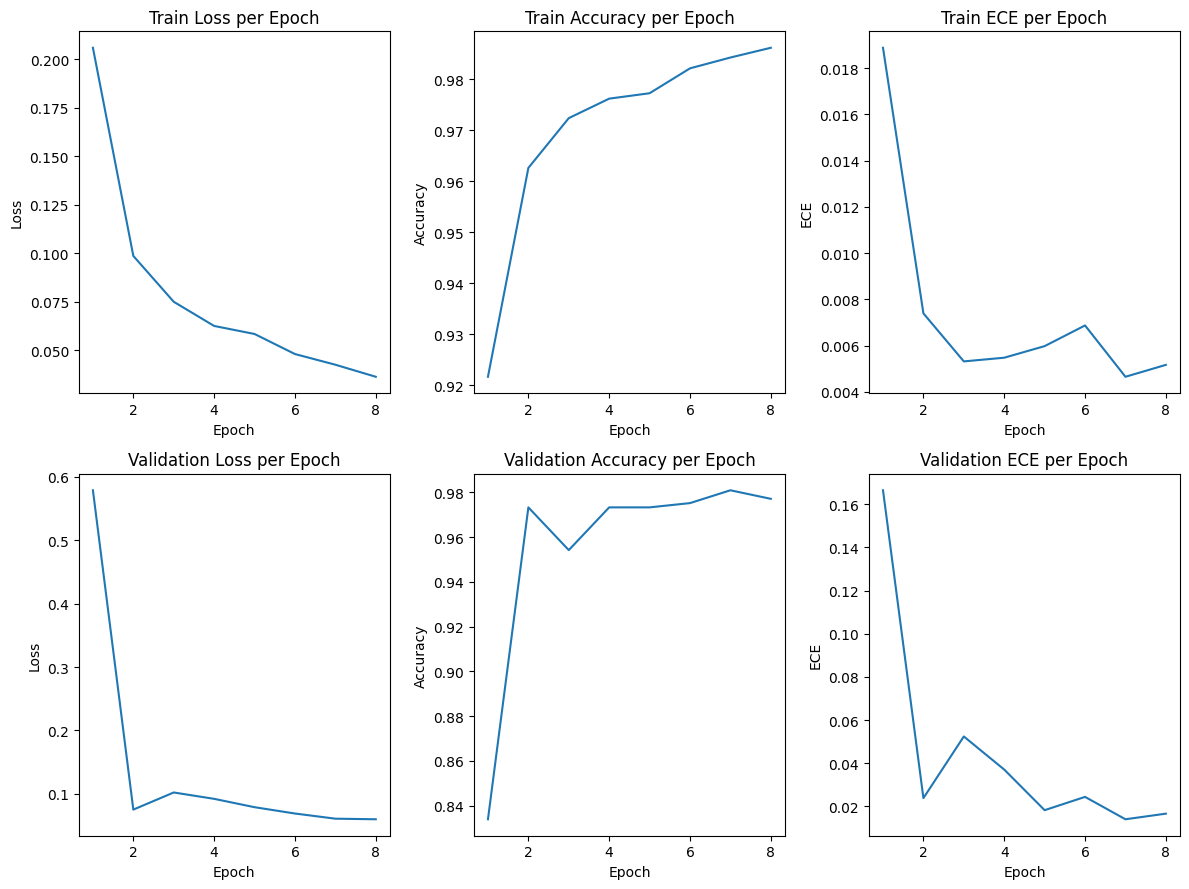

In [128]:
import numpy as np
import matplotlib.pyplot as plt

epoch_axis = np.arange(1, EPOCHS+1)
figure = plt.figure(figsize=(12, 9))

# Losses
figure.add_subplot(2, 3, 1)
plt.plot(epoch_axis, train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Loss per Epoch")

figure.add_subplot(2, 3, 4)
plt.plot(epoch_axis, val_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss per Epoch")

# Accuracies
figure.add_subplot(2, 3, 2)
plt.plot(epoch_axis, train_accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train Accuracy per Epoch")

figure.add_subplot(2, 3, 5)
plt.plot(epoch_axis, val_accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy per Epoch")

# ECEs
figure.add_subplot(2, 3, 3)
plt.plot(epoch_axis, train_eces)
plt.xlabel("Epoch")
plt.ylabel("ECE")
plt.title("Train ECE per Epoch")

figure.add_subplot(2, 3, 6)
plt.plot(epoch_axis, val_eces)
plt.xlabel("Epoch")
plt.ylabel("ECE")
plt.title("Validation ECE per Epoch")

plt.tight_layout()
plt.show()


In [129]:
# ==== Calculate validation accuracy and AUROC after training ====
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

model.eval()
yv, pv = [], []
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        out = model(x)
        prob = torch.softmax(out, dim=1).cpu().numpy()
        pv.append(prob)
        yv.append(y.cpu().numpy())
yv = np.concatenate(yv, 0)
pv = np.concatenate(pv, 0)
val_acc = accuracy_score(yv, np.argmax(pv, axis=1))
try:
    val_auroc = roc_auc_score(yv, pv[:, 1])
except Exception:
    val_auroc = float('nan')
print(f"VAL | acc={val_acc:.4f} auroc={val_auroc:.4f}")

VAL | acc=0.9771 auroc=0.9972


In [130]:
# Predicted probabilities on validation set

model.eval()
all_probs = []
all_targets = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # Probability for label = 1
        all_probs.append(probs.cpu().numpy())
        all_targets.append(labels.cpu().numpy())

all_probs = np.concatenate(all_probs)
all_targets = np.concatenate(all_targets).flatten()

# Print first 5 sample probs with label
for idx in range(5):
    print(f"Sample {idx} - label = {all_targets[idx]} ; prob = {all_probs[idx]}")

Sample 0 - label = 1 ; prob = 0.9999809265136719
Sample 1 - label = 1 ; prob = 0.9999867677688599
Sample 2 - label = 1 ; prob = 0.9999183416366577
Sample 3 - label = 0 ; prob = 5.7024802657679174e-09
Sample 4 - label = 1 ; prob = 0.9999969005584717


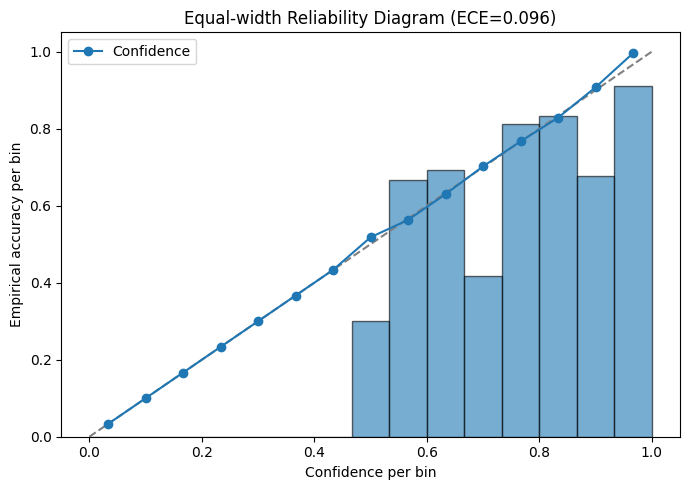

ECE = 0.0959


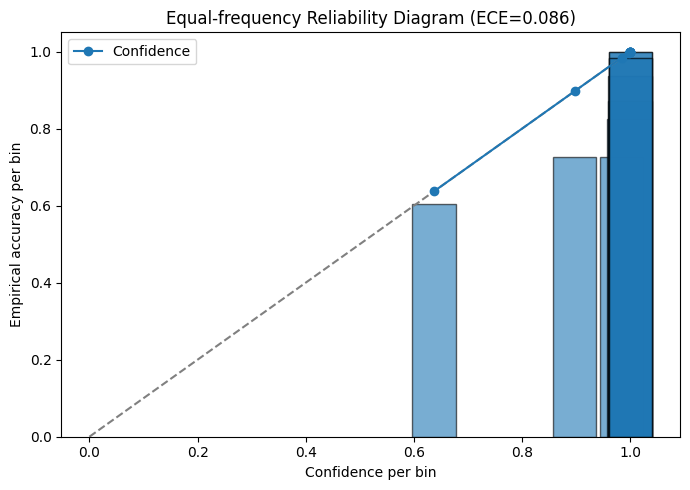

Equal-frequency ECE: 0.0858


In [131]:
def save_reliability_diagram(y_true, y_prob, n_bins=15, out_file="reliability_resnet18_head.png"):
    confidences = np.max(y_prob, axis=1)
    preds = np.argmax(y_prob, axis=1)
    correct = (preds == y_true).astype(np.float32)
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    xs = np.linspace(0.5/n_bins, 1-0.5/n_bins, n_bins)
    bin_accs, bin_confs, bin_counts = [], [], []

    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (confidences > lo) & (confidences <= hi) if i > 0 else (confidences >= lo) & (confidences <= hi)
        if mask.sum() == 0:
            bin_accs.append(0.0)
            bin_confs.append((lo+hi)/2)
            bin_counts.append(0)
            continue
        acc_i = correct[mask].mean()
        conf_i = confidences[mask].mean()
        frac_i = mask.mean()
        ece += abs(acc_i - conf_i) * frac_i
        bin_accs.append(acc_i)
        bin_confs.append(conf_i)
        bin_counts.append(mask.sum())

    plt.figure(figsize=(7,5))
    plt.plot([0,1],[0,1], linestyle='--', color='gray')
    plt.bar(xs, bin_accs, width=1.0/n_bins, alpha=0.6, edgecolor='k')
    plt.plot(xs, bin_confs, marker='o', label='Confidence')
    plt.xlabel('Confidence per bin')
    plt.ylabel('Empirical accuracy per bin')
    plt.title(f'Equal-width Reliability Diagram (ECE={ece:.3f})')
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_file, dpi=150)
    plt.show()
    return float(ece)

ece = save_reliability_diagram(yt, pt, n_bins=15, out_file="reliability_resnet18_head.png")
print(f'ECE = {ece:.4f}')

from cProfile import label
import matplotlib.pyplot as plt
import numpy as np

def reliability_diagram_equalfreq(y_true, y_prob, n_bins=10, out_file="reliability_eqfreq.png"):
    """
    Plots and saves an equal-frequency reliability diagram (no bin count histogram).
    """
    confidences = np.max(y_prob, axis=1)
    preds = np.argmax(y_prob, axis=1)
    correct = (preds == y_true).astype(np.float32)

    # Calculate equal-frequency (quantile) bin edges
    quantiles = np.linspace(0, 1, n_bins+1)
    bin_edges = np.quantile(confidences, quantiles)
    # Safety: force endpoints to cover [0, 1]
    bin_edges[0] = 0.0
    bin_edges[-1] = 1.0

    bin_accs, bin_confs, xs = [], [], []
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i+1]
        # All bins (except first) are open on the left, closed on the right
        mask = (confidences >= lo) & (confidences <= hi) if i == 0 else (confidences > lo) & (confidences <= hi)
        if mask.sum() == 0:
            bin_accs.append(0.0)
            bin_confs.append((lo+hi)/2)
            xs.append((lo+hi)/2)
            continue
        acc_i = correct[mask].mean()
        conf_i = confidences[mask].mean()
        frac_i = mask.sum() / len(confidences)
        ece += abs(acc_i - conf_i) * frac_i
        bin_accs.append(acc_i)
        bin_confs.append(conf_i)
        xs.append(conf_i)  # plot at mean confidence per bin

    plt.figure(figsize=(7,5))
    plt.plot([0,1], [0,1], linestyle='--', color='gray')
    plt.bar(xs, bin_accs, width=0.08, alpha=0.6, edgecolor='k')
    plt.plot(xs, bin_confs, marker='o', label='Confidence')
    plt.xlabel('Confidence per bin')
    plt.ylabel('Empirical accuracy per bin')
    plt.title(f'Equal-frequency Reliability Diagram (ECE={ece:.3f})')
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_file, dpi=150)
    plt.show()
    return float(ece)

# Example usage for your validation or test results:
ece_eqfreq = reliability_diagram_equalfreq(yt, pt, n_bins=10, out_file="reliability_resnet18_head_eqfreq.png")
print(f'Equal-frequency ECE: {ece_eqfreq:.4f}')

Validation sample 0 - label = 1 ; probs = [1.9024346e-05 9.9998093e-01]
Validation sample 1 - label = 1 ; probs = [1.3270525e-05 9.9998677e-01]
Validation sample 2 - label = 1 ; probs = [8.1685466e-05 9.9991834e-01]
Validation sample 3 - label = 0 ; probs = [1.0000000e+00 5.7024803e-09]
Validation sample 4 - label = 1 ; probs = [3.0710698e-06 9.9999690e-01]


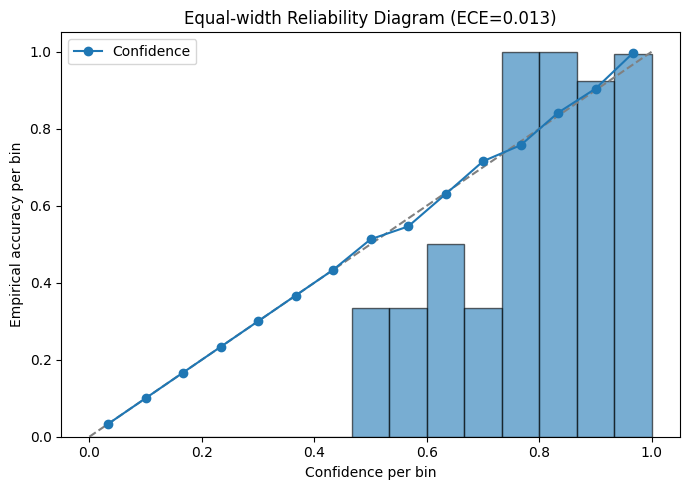

Validation ECE = 0.0134


In [132]:
# --- Compute and save reliability diagram/ECE on the VALIDATION set ---

import numpy as np

# Gather validation probabilities and labels
model.eval()
val_probs = []
val_targets = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)  # [batch, 2]
        val_probs.append(probs.cpu().numpy())
        val_targets.append(labels.cpu().numpy())

val_probs = np.concatenate(val_probs, axis=0)        # shape [n_val, 2]
val_targets = np.concatenate(val_targets, axis=0).flatten()  # shape [n_val]

# Print first 5 sample probs with label (for sanity check)
for idx in range(5):
    print(f"Validation sample {idx} - label = {val_targets[idx]} ; probs = {val_probs[idx]}")

def save_reliability_diagram(y_true, y_prob, n_bins=15, out_file="reliability_resnet18_head_VAL.png"):
    import matplotlib.pyplot as plt
    confidences = np.max(y_prob, axis=1)
    preds = np.argmax(y_prob, axis=1)
    correct = (preds == y_true).astype(np.float32)
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    xs = np.linspace(0.5/n_bins, 1-0.5/n_bins, n_bins)
    bin_accs, bin_confs = [], []

    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (confidences > lo) & (confidences <= hi) if i > 0 else (confidences >= lo) & (confidences <= hi)
        if mask.sum() == 0:
            bin_accs.append(0.0)
            bin_confs.append((lo+hi)/2)
            continue
        acc_i = correct[mask].mean()
        conf_i = confidences[mask].mean()
        frac_i = mask.mean()
        ece += abs(acc_i - conf_i) * frac_i
        bin_accs.append(acc_i)
        bin_confs.append(conf_i)

    plt.figure(figsize=(7,5))
    plt.plot([0,1],[0,1], linestyle='--', color='gray')
    plt.bar(xs, bin_accs, width=1.0/n_bins, alpha=0.6, edgecolor='k')
    plt.plot(xs, bin_confs, marker='o', label='Confidence')
    plt.xlabel('Confidence per bin')
    plt.ylabel('Empirical accuracy per bin')
    plt.title(f'Equal-width Reliability Diagram (ECE={ece:.3f})')
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_file, dpi=150)
    plt.show()
    return float(ece)

# Generate and save the reliability diagram for validation set
ece_val = save_reliability_diagram(val_targets, val_probs, n_bins=15, out_file="reliability_resnet18_head_VAL.png")
print(f'Validation ECE = {ece_val:.4f}')

== Example misclassified test set samples ==

Sample 1: idx=103
- True: normal
- Pred: pneumonia
- Prob(Pred): 1.00
- Comment: Highly confident but wrong – possibly poor image quality, artifact, or challenging case.

Sample 2: idx=9
- True: normal
- Pred: pneumonia
- Prob(Pred): 1.00
- Comment: Highly confident but wrong – possibly poor image quality, artifact, or challenging case.

Sample 3: idx=125
- True: normal
- Pred: pneumonia
- Prob(Pred): 1.00
- Comment: Highly confident but wrong – possibly poor image quality, artifact, or challenging case.

Sample 4: idx=370
- True: normal
- Pred: pneumonia
- Prob(Pred): 1.00
- Comment: Highly confident but wrong – possibly poor image quality, artifact, or challenging case.

Sample 5: idx=611
- True: normal
- Pred: pneumonia
- Prob(Pred): 1.00
- Comment: Highly confident but wrong – possibly poor image quality, artifact, or challenging case.

Saved figure as misclassified_gallery.png


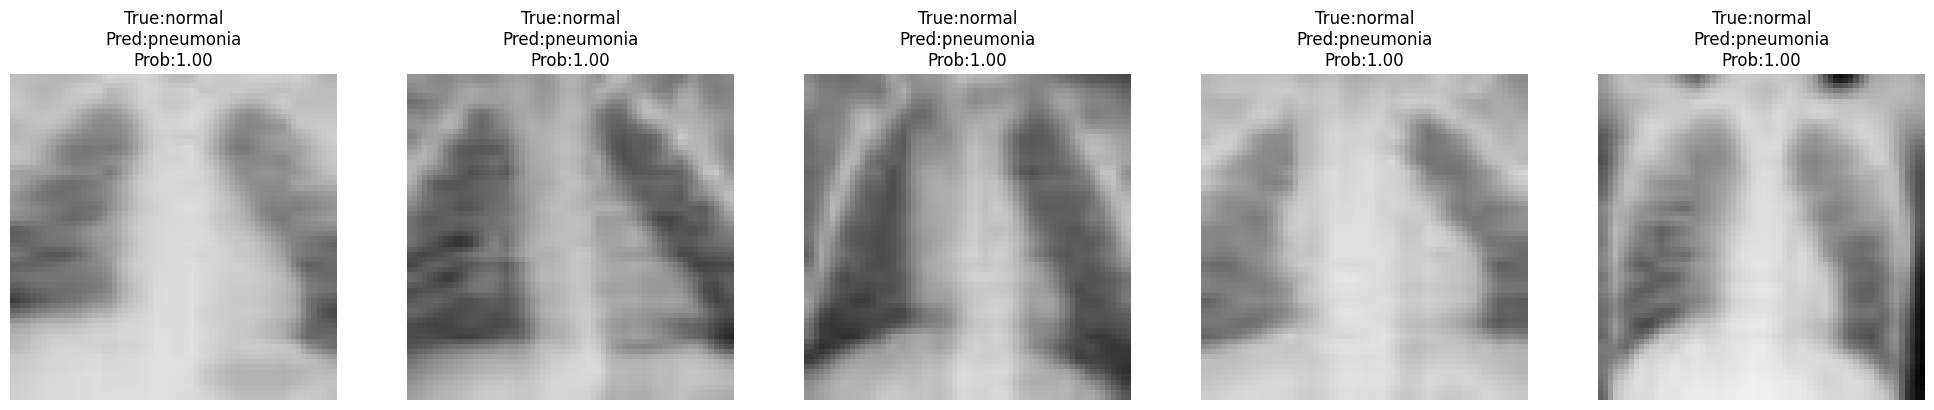

In [133]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Gather all predictions, labels, and original images from the test set.
model.eval()
test_probs = []
test_targets = []
test_imgs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)               # [batch, 2]
        test_probs.append(probs.cpu().numpy())
        test_targets.append(labels.cpu().numpy())
        test_imgs.append(images.cpu().numpy())              # [B, 3, H, W]

test_probs = np.concatenate(test_probs, axis=0)              # [N, 2]
test_targets = np.concatenate(test_targets, axis=0).flatten()# [N]
test_imgs = np.concatenate(test_imgs, axis=0)                # [N, 3, H, W]
test_preds = np.argmax(test_probs, axis=1)                   # [N]

# 2. Find all true misclassifications
mis_idx = np.where(test_preds != test_targets)[0]
n_mis = len(mis_idx)

if n_mis == 0:
    print("🎉 No misclassified samples found in the test set!")
    # Optionally: show a random selection of correctly classified 'hard' cases, or just print a message
else:
    # 3. Sort the misclassified samples by model confidence (descending)
    mis_confidences = test_probs[mis_idx, test_preds[mis_idx]]
    sort_idx = np.argsort(-mis_confidences)
    chosen_idx = mis_idx[sort_idx[:min(5, n_mis)]]

    print("== Example misclassified test set samples ==")
    fig, axs = plt.subplots(1, len(chosen_idx), figsize=(4*len(chosen_idx), 4))
    if len(chosen_idx) == 1: axs = [axs]
    label_names = list(INFO[DATASET_KEY]['label'].values())

    for i, idx in enumerate(chosen_idx):
        img = test_imgs[idx].transpose(1,2,0)   # [H,W,C]
        true_lbl = int(test_targets[idx])
        pred_lbl = int(test_preds[idx])
        prob = float(test_probs[idx, pred_lbl])

        # For grayscale images (C=1), remove channel axis for imshow
        if img.shape[2] == 1:
            axs[i].imshow(img.squeeze(), cmap='gray')
        else:
            axs[i].imshow(img)
        axs[i].axis('off')
        axs[i].set_title(f"True:{label_names[true_lbl]}\nPred:{label_names[pred_lbl]}\nProb:{prob:.2f}")

        # Print commentary block for README copying
        print(f"\nSample {i+1}: idx={idx}")
        print(f"- True: {label_names[true_lbl]}")
        print(f"- Pred: {label_names[pred_lbl]}")
        print(f"- Prob(Pred): {prob:.2f}")
        # Suggest a (placeholder) hypothesis
        if prob > 0.95:
            print("- Comment: Highly confident but wrong – possibly poor image quality, artifact, or challenging case.")
        elif prob > 0.7:
            print("- Comment: Model moderately confident. Borderline appearance, possibly ambiguous or mixed features.")
        else:
            print("- Comment: Model had low confidence – this could be a 'border' or out-of-distribution case.")
    plt.tight_layout()
    plt.savefig("misclassified_gallery.png", dpi=150)
    print("\nSaved figure as misclassified_gallery.png")